# GENE7 — supervised morphology contrasts: crispant vs matched control

**Question.** Within a stage- and temperature-matched stratum, is there a direction in morphology
space that separates a crispant target from its controls — and if so, does each embryo's *signed
distance* along that direction generalise well enough to use as a graded severity score?

**Why this and not the intra-cohort PCs.** The unsupervised cohort axes in `gene7_cohort_axes.ipynb`
found real, interpretable phenotype, but nothing forced them to point at the perturbation. This
notebook asks the supervised version. The resulting distance `s` is the intended replacement for the
binary crispant/control indicator in the PLN regressions.

**The premise being tested.** Crispants are mosaic F0s, so an injected clutch is a mixture of
effectively-null and escaper embryos. A binary label misclassifies the escapers, which attenuates
the contrast; a graded score partially recovers the dose. If that story is right, crispant groups
should be *more dispersed* along the discriminant than their controls.

**This notebook is homework, not the result.** It decides which contrasts have an axis worth
regressing on. No sequencing data is touched.

---

### Design

| | |
|---|---|
| space | first 5 axes of the GENE7-native 10-component PCA on `z_mu_b_*`, unwhitened |
| contrast | 3 targets × 4 temperatures × 3 timepoints = 36, controls matched within each cell |
| estimator | shrunken LDA (Ledoit–Wolf), equal priors |
| score | `s = (w·x + b) / ‖w‖`, signed, positive toward crispant |

Two caveats that hold throughout. Controls are **shared across the three targets** within a
condition, so the 36 contrasts are not independent. And every statistic here has a null that is not
zero: chance AUC is 0.5, and two arbitrary directions in 5D sit a median of ~70° apart, not 90°.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parents[2] / "src"))

import lda_contrasts as lc
import lda_plots as lp

lp.use_house_style()
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

DATA = HERE / "data" / "lda"
FIGURES = HERE / "figures" / "lda"

# --- shared figure/exclusion config (see gene7_config.py) ---
import gene7_config as cfg
FIGURES = cfg.figure_dir("lda_contrasts")
print(f"excluding {cfg.EXCLUDED_CONTRASTS} | figures -> {FIGURES}")


excluding ['atf6 vs ctrl | 34C | 30hpf'] | figures -> /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts


## 1. The shared coordinate system

Read from `data/gene7_global_scores.csv` rather than refit, so these contrasts live in exactly the
basis the cohort-PC covariates already use.


In [2]:
scores = pd.read_csv(HERE / "data" / "gene7_global_scores.csv")
columns = lc.shared_columns(scores)
print(f"{len(scores)} GENE7 wells (curated image-QC exclusions already applied)")
print(f"shared subspace: {columns}")

design = (
    scores.pivot_table(index="perturbation_group", columns=["temperature", "timepoint_seq"],
                       values="well_id", aggfunc="count")
    .fillna(0).astype(int)
)
design


553 GENE7 wells (curated image-QC exclusions already applied)
shared subspace: ['G00', 'G01', 'G02', 'G03', 'G04']


temperature         24          28          34          35        
timepoint_seq       24  30  36  24  30  36  24  30  36  24  30  36
perturbation_group                                                
Control             12  12  12  11  12  11  12  12  12  12  10  12
atf6                10  11  12  11  11  10  12  12  11  11  11  12
ctcf                11  12  12  11  11  12  12  12  11  12  12  12
wfs1a,wfs1b         12  12  12  11  12  12  12  12  12   9  12  11

Every crispant cell has a control cell at the identical temperature and timepoint — the matching is
by design, not by modelling.


In [3]:
axes = lc.fit_all_contrasts(scores, verbose=False)
summary = lc.contrast_summary(axes)
per_embryo = lc.contrast_scores(axes)
directions = lc.contrast_directions(axes)
similarity = lc.direction_similarity(axes)
print(f"{len(axes)} contrasts fitted")


36 contrasts fitted


## 2. Does the axis generalise?

The headline number is **leave-one-out AUC**: each embryo scored by a discriminant fit on the other
n−1. This is deliberately not in-sample separation. At 11-vs-12 in 5D the classes are nearly always
separable in-sample, so an in-sample statistic would be near-perfect everywhere and tell us nothing.
The p-values come from label permutation, re-running the full LOO procedure each time.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/00_auc_heatmap.png')

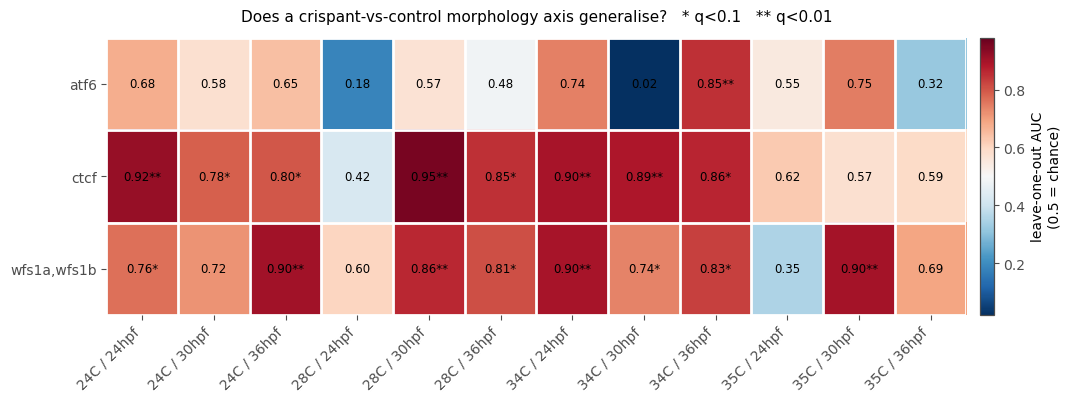

In [4]:
figure = lp.auc_heatmap(summary)
lp.save_inline(figure, FIGURES / "00_auc_heatmap")


Read the `atf6` row against the others. Two of its cells sit at AUC 0.02 and 0.18 — *below* chance,
which is what an axis fit entirely to noise looks like: in-sample the classes separate, out-of-sample
the direction points backwards. That is the failure mode LOO exists to expose, and it is invisible to
Hotelling's T² or to any in-sample measure.

**Why several respectable-looking AUCs are not significant.** The null for this statistic is not
"0.5 plus a little noise". At ~11 per group, a *shuffled* labelling still reaches AUC 0.69–0.76 at
its 95th percentile, because shrunken LDA in 5D can partially fit any split of these embryos. The
column below is the bar each contrast actually had to clear.


In [5]:
bar = summary.sort_values("loo_auc", ascending=False)[
    ["contrast", "n_crispant", "n_control", "loo_auc", "null_auc_p95", "perm_p_auc", "q_auc"]
].copy()
bar["clears_null_p95"] = bar["loo_auc"] > bar["null_auc_p95"]
bar.round(3).reset_index(drop=True).head(24)


,contrast,n_crispant,n_control,loo_auc,null_auc_p95,perm_p_auc,q_auc,clears_null_p95
0,ctcf vs ctrl | 28C | 30hpf,11,12,0.955,0.735,0.001,0.007,True
1,ctcf vs ctrl | 24C | 24hpf,11,12,0.917,0.735,0.001,0.007,True
2,"wfs1a,wfs1b vs ctrl | 24C | 36hpf",12,12,0.903,0.743,0.001,0.007,True
3,"wfs1a,wfs1b vs ctrl | 35C | 30hpf",12,10,0.900,0.733,0.002,0.008,True
4,"wfs1a,wfs1b vs ctrl | 34C | 24hpf",12,12,0.896,0.736,0.001,0.007,True
5,ctcf vs ctrl | 34C | 24hpf,12,12,0.896,0.722,0.002,0.008,True
6,ctcf vs ctrl | 34C | 30hpf,12,12,0.889,0.729,0.002,0.008,True
7,ctcf vs ctrl | 34C | 36hpf,11,12,0.864,0.735,0.003,0.011,True
8,"wfs1a,wfs1b vs ctrl | 28C | 30hpf",12,12,0.861,0.709,0.001,0.007,True
9,ctcf vs ctrl | 28C | 36hpf,12,11,0.848,0.727,0.005,0.016,True


In [6]:
gates = pd.DataFrame({
    "permutation q<0.10 (LOO-AUC)": [(summary["q_auc"] < 0.10).sum()],
    "Hotelling p<0.05":             [(summary["hotelling_p"] < 0.05).sum()],
    "better determined than random":[(summary["boot_angle_p95"] < summary["random_angle_median"]).sum()],
    "usable (AUC gate AND stability gate)": [summary["usable"].sum()],
    "stage-confounded (angle<35°)": [summary["stage_confounded"].sum()],
}, index=[f"of {len(summary)}"]).T
gates


,of 36
permutation q<0.10 (LOO-AUC),17
Hotelling p<0.05,13
better determined than random,28
usable (AUC gate AND stability gate),16
stage-confounded (angle<35°),3


## 3. Where the embryos actually sit

One panel per condition, per target. The vertical dashed line is the hyperplane. This is the figure
that answers the dilution worry directly: if controls spread as widely along `s` as crispants do,
then a continuous score is carrying variation a binary label would have suppressed — and whether
that variation is signal or noise becomes an empirical question rather than an assumption.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/01_score_panels_ctcf.png')

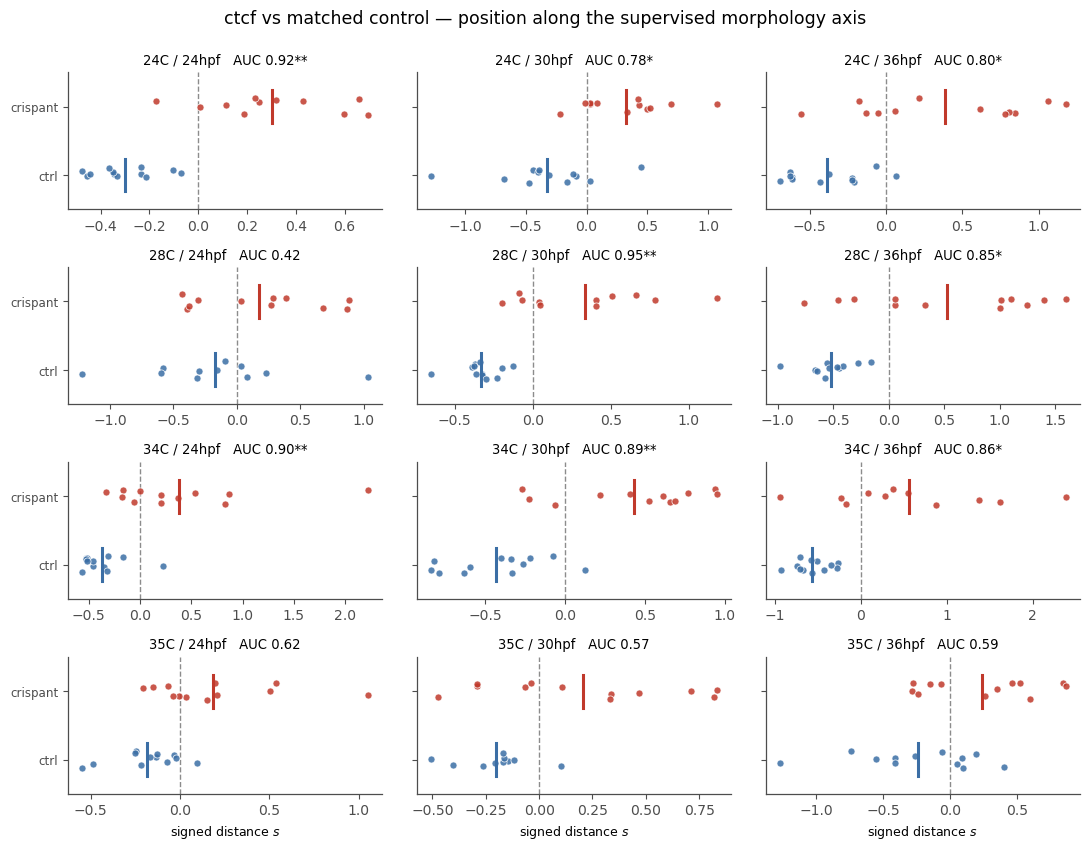

In [7]:
figure = lp.score_panels(per_embryo, summary, target="ctcf")
lp.save_inline(figure, FIGURES / "01_score_panels_ctcf")


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/02_score_panels_wfs1a-wfs1b.png')

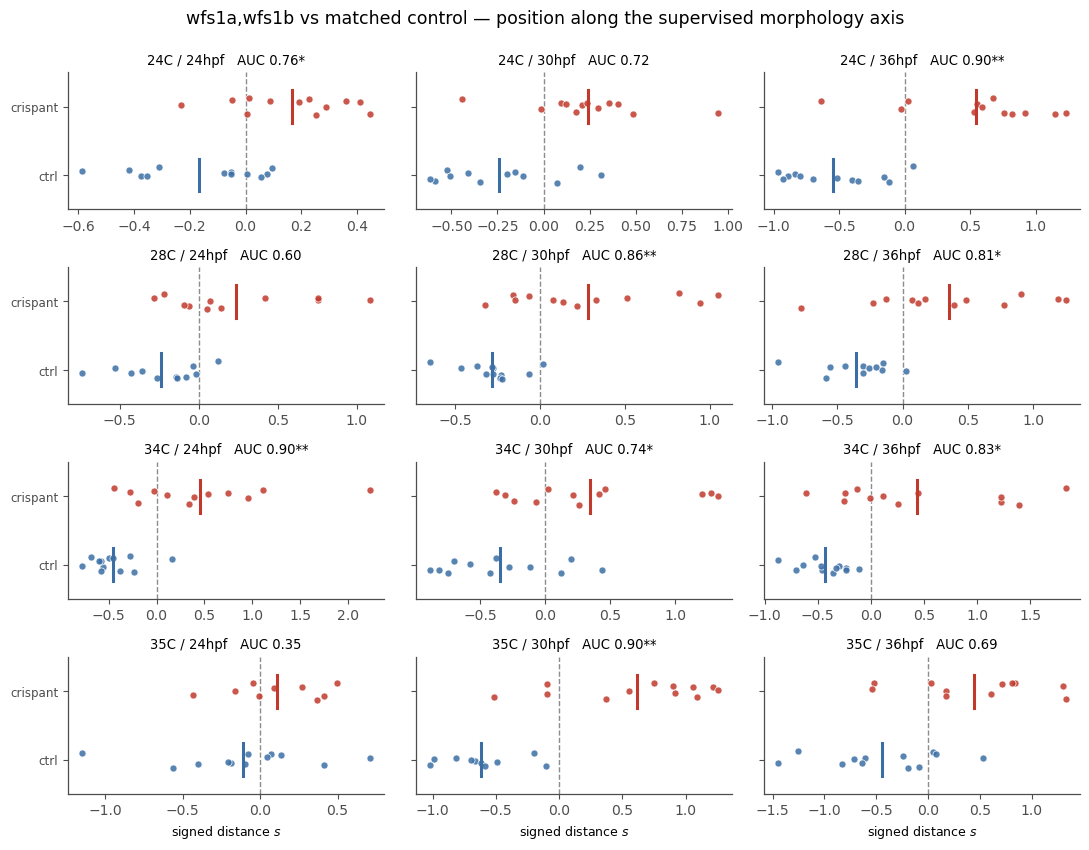

In [8]:
figure = lp.score_panels(per_embryo, summary, target="wfs1a,wfs1b")
lp.save_inline(figure, FIGURES / "02_score_panels_wfs1a-wfs1b")


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/03_score_panels_atf6.png')

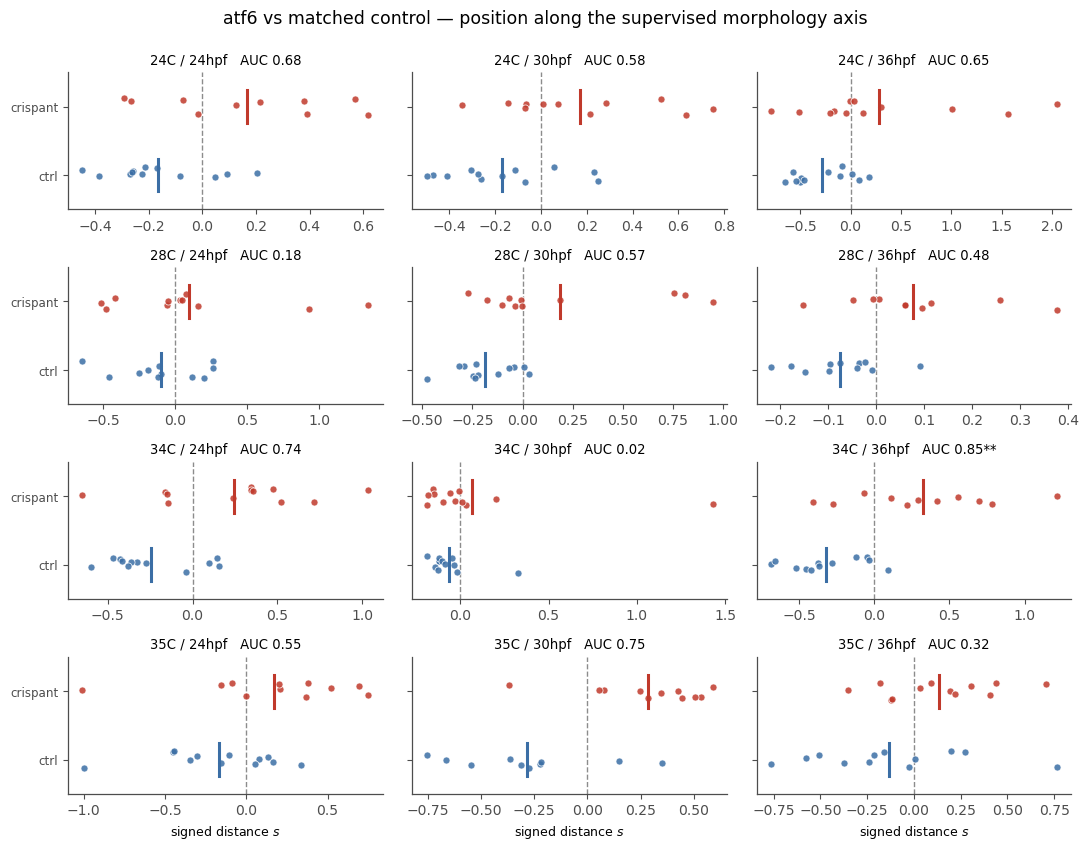

In [9]:
figure = lp.score_panels(per_embryo, summary, target="atf6")
lp.save_inline(figure, FIGURES / "03_score_panels_atf6")


## 4. The mosaic-F0 premise

If injected clutches mix effective nulls with escapers, they should be more dispersed than controls
along the axis that separates them. Because the discriminant is refit on every permuted labelling,
the accompanying null answers the obvious objection: *would an arbitrary split of these same embryos
show one side more spread out, once a discriminant is fit to it?*


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/04_dispersion_scatter.png')

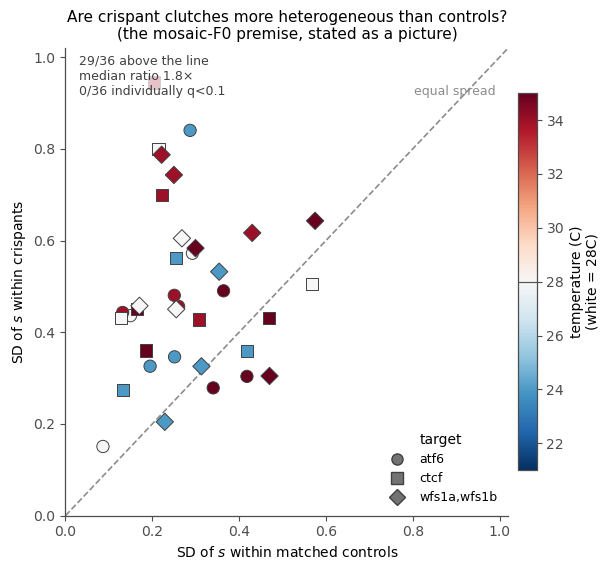

In [10]:
figure, dispersion = lp.dispersion_scatter(per_embryo, summary)
lp.save_inline(figure, FIGURES / "04_dispersion_scatter")


**Note the split verdict, because it matters for how this gets described.** No single contrast clears
its own permutation null — a variance ratio estimated from ~11 vs ~12 embryos simply has no power.
The evidence is entirely in the *consistency*: 29 of 36 contrasts point the same way, at a median
ratio of ~1.8×. That is a strong aggregate result and a null result per contrast, and it should be
reported as both.


In [11]:
dispersion.sort_values("log_sd_ratio", ascending=False).head(10).round(3)


,contrast,target,temperature,sd_control,sd_crispant,loo_auc,q_auc,log_sd_ratio,perm_p_dispersion,q_dispersion
20,ctcf vs ctrl | 34C | 36hpf,ctcf,34.0,0.204,0.945,0.864,0.011,1.534,0.028,0.168
17,ctcf vs ctrl | 28C | 36hpf,ctcf,28.0,0.215,0.800,0.848,0.016,1.315,0.046,0.184
32,"wfs1a,wfs1b vs ctrl | 34C | 36hpf","wfs1a,wfs1b",34.0,0.222,0.787,0.826,0.027,1.268,0.062,0.186
7,atf6 vs ctrl | 34C | 30hpf,atf6,34.0,0.132,0.443,0.021,0.996,1.212,0.058,0.186
16,ctcf vs ctrl | 28C | 30hpf,ctcf,28.0,0.129,0.431,0.955,0.007,1.209,0.008,0.144
18,ctcf vs ctrl | 34C | 24hpf,ctcf,34.0,0.222,0.699,0.896,0.008,1.148,0.106,0.201
30,"wfs1a,wfs1b vs ctrl | 34C | 24hpf","wfs1a,wfs1b",34.0,0.250,0.743,0.896,0.007,1.090,0.037,0.180
2,atf6 vs ctrl | 24C | 36hpf,atf6,24.0,0.287,0.840,0.646,0.242,1.074,0.085,0.198
4,atf6 vs ctrl | 28C | 30hpf,atf6,28.0,0.150,0.436,0.568,0.438,1.069,0.040,0.180
22,ctcf vs ctrl | 35C | 30hpf,ctcf,35.0,0.165,0.450,0.575,0.438,1.005,0.004,0.144


## 5. Is the direction determined, or arbitrary?

Separation and stability are different properties. A contrast can have significantly different
centroids and still recover a near-arbitrary direction under resampling — which would make `s`
meaningless for any embryo the axis was not built around. The grey band is where an arbitrary 5D
direction lands.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/05_stability_plot.png')

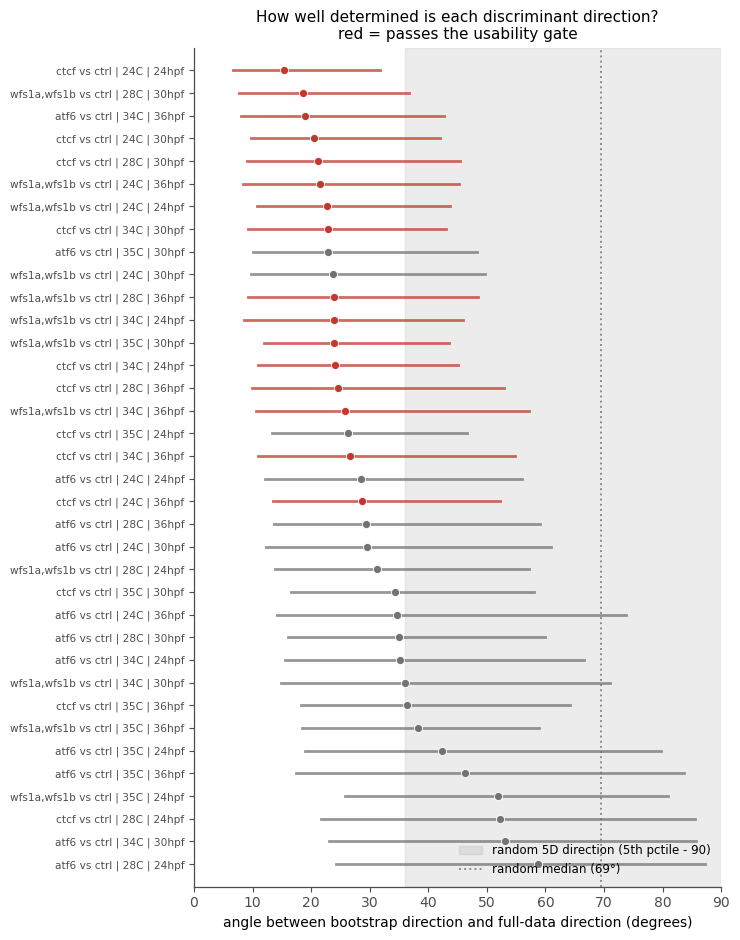

In [12]:
figure = lp.stability_plot(axes, summary)
lp.save_inline(figure, FIGURES / "05_stability_plot")


## 5b. Consequential variability — does the *ordering* survive?

The angle above is a property of the estimator. What a regression on `s` actually consumes is the
**ordering** of embryos, so that is what should be measured: refit on each bootstrap, re-score every
original embryo, and Spearman-correlate against the full-data ordering.

The two can come apart, for a concrete geometric reason. The angle is measured in the ambient
Euclidean metric, but the embryos do not fill that space — within the 5D subspace, G00 alone carries
~49% of the variance. A direction perturbation lying mostly orthogonal to where the embryos actually
sit barely moves any score, so a 45° wobble can leave the ranking untouched.

**The floor is doubly important here.** Because the cloud is anisotropic, two *arbitrary* directions
already order these same embryos at ρ ≈ 0.47 with no information at all. So each contrast is tested
against its own random-direction null, with the observed bootstrap median compared against the full
null distribution — not one tail against the other.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/06_rank_stability_plot.png')

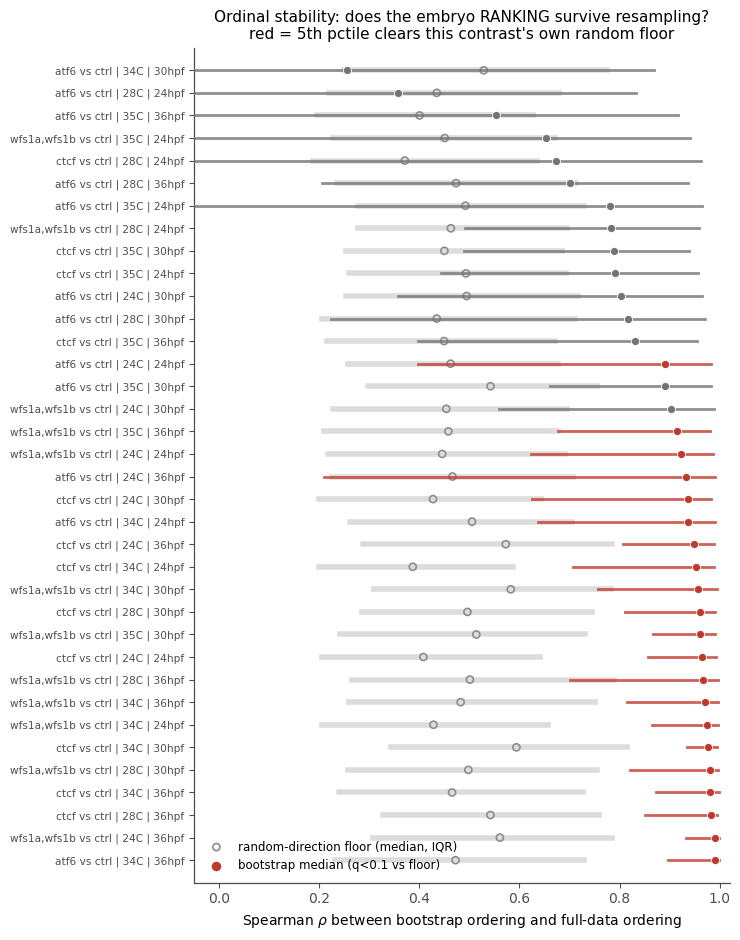

In [13]:
figure = lp.rank_stability_plot(axes, summary)
lp.save_inline(figure, FIGURES / "06_rank_stability_plot")


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/07_angle_versus_rank.png')

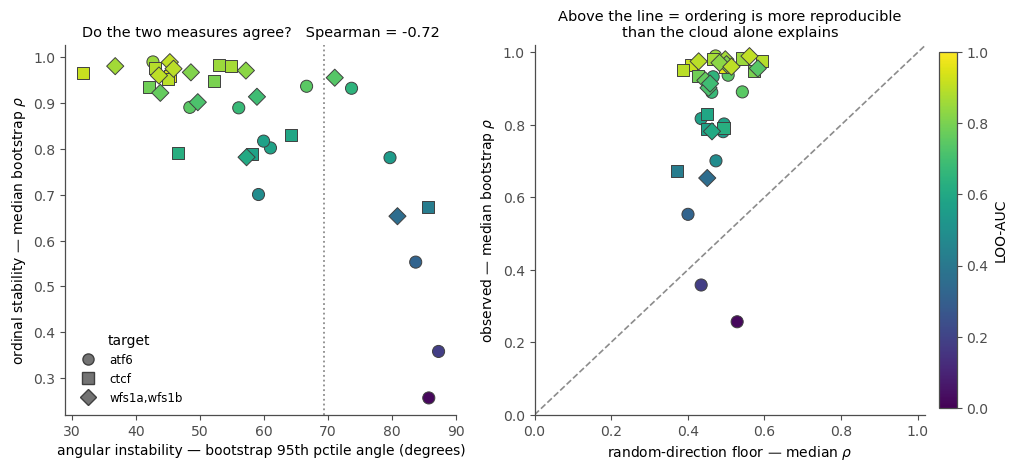

In [14]:
figure = lp.angle_versus_rank(summary)
lp.save_inline(figure, FIGURES / "07_angle_versus_rank")


**Verdict: the ordinal measure is the better one to quote, but here it does not change the call.**

The left panel shows why the instinct was sound — the relationship is strong (Spearman −0.72) but
badly *nonlinear*. Below ~70° of angular wobble, ordinal stability is uniformly high (ρ ≈ 0.78–1.0)
and the angle barely discriminates within that range; past 70° it falls off a cliff. So the angle
saturates exactly where the working contrasts live, and reading a 45° spread as "half-arbitrary"
overstates the damage. The ordinal number says what it costs: essentially nothing.

Where it lands in practice: the ordinal gate passes **17/36** against the angular gate's **16/36**,
and the two agree on **35/36** contrasts. Different instrument, same reading — which is a useful
thing to know rather than a wasted check, because it means the earlier stability conclusions do not
need revisiting.

Top-tercile retention tells the same story in the units that matter for a severity score: 0.875
observed against a 0.625 floor, i.e. the severe end stays the severe end.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/08_rank_churn_figure.png')

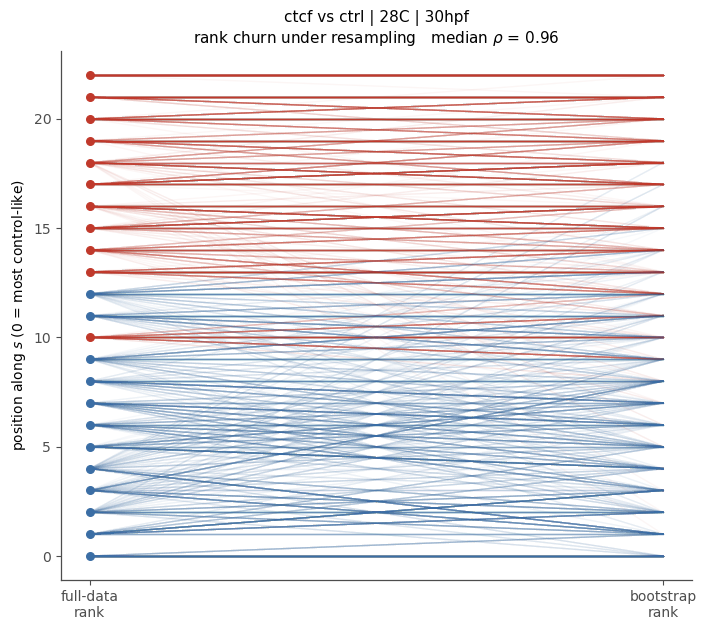

In [15]:
best = summary.sort_values("loo_auc", ascending=False)["contrast"].iloc[0]
figure = lp.rank_churn_figure(next(a for a in axes if a.label == best))
lp.save_inline(figure, FIGURES / "08_rank_churn_figure")


In [16]:
summary.sort_values("rank_rho_median", ascending=False)[
    ["contrast", "loo_auc", "boot_angle_p95", "rank_rho_median", "random_rank_rho_median",
     "rank_p_vs_floor", "q_rank", "top_retention_median", "loo_rank_rho",
     "usable", "usable_ordinal"]
].round(3).reset_index(drop=True)


,contrast,loo_auc,boot_angle_p95,rank_rho_median,random_rank_rho_median,rank_p_vs_floor,q_rank,top_retention_median,loo_rank_rho,usable,usable_ordinal
0,atf6 vs ctrl | 34C | 36hpf,0.848,42.632,0.990,0.472,0.008,0.045,0.875,0.991,True,True
1,"wfs1a,wfs1b vs ctrl | 24C | 36hpf",0.903,45.275,0.990,0.561,0.002,0.030,0.875,0.987,True,True
2,ctcf vs ctrl | 28C | 36hpf,0.848,52.961,0.983,0.542,0.008,0.045,0.875,0.987,True,True
3,ctcf vs ctrl | 34C | 36hpf,0.864,54.847,0.981,0.465,0.012,0.050,1.000,0.984,True,True
4,"wfs1a,wfs1b vs ctrl | 28C | 30hpf",0.861,36.730,0.981,0.498,0.010,0.050,1.000,0.991,True,True
5,ctcf vs ctrl | 34C | 30hpf,0.889,42.987,0.977,0.594,0.032,0.074,1.000,0.977,True,True
6,"wfs1a,wfs1b vs ctrl | 34C | 24hpf",0.896,45.850,0.975,0.428,0.000,0.000,0.875,0.990,True,True
7,"wfs1a,wfs1b vs ctrl | 34C | 36hpf",0.826,57.168,0.971,0.483,0.018,0.057,0.875,0.984,True,True
8,"wfs1a,wfs1b vs ctrl | 28C | 36hpf",0.811,48.567,0.967,0.501,0.035,0.074,0.875,0.947,True,True
9,ctcf vs ctrl | 24C | 24hpf,0.917,31.717,0.965,0.408,0.000,0.000,0.938,0.962,True,True


## 6. Interpretation checks: what else is the axis parallel to?

**Stage.** Morphology encodes developmental stage strongly, and controls at three timepoints give
the stage direction directly, estimated from unperturbed embryos only. A discriminant near-parallel
to it is a delay score, and any transcriptional hit would be a stage-composition shift in disguise.

**The unsupervised cohort PC1.** Near 0° means the supervised axis recovers what the intra-cohort
PCA already found. Near the random median means the perturbation direction is a *minor* axis of
within-cohort variation — real phenotype dominating the cohort, but not the phenotype that separates
crispant from control.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/09_confound_scatter.png')

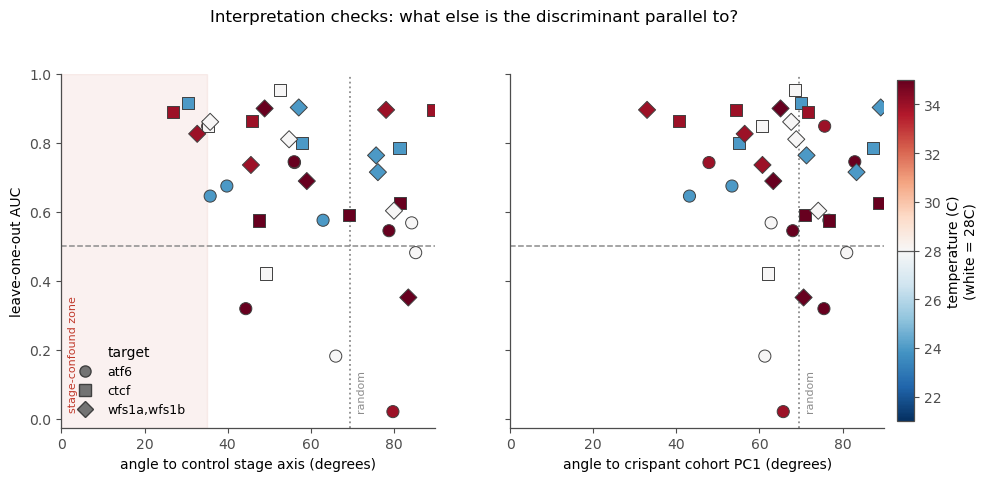

In [17]:
figure = lp.confound_scatter(summary)
lp.save_inline(figure, FIGURES / "09_confound_scatter")


In [18]:
strong = summary.loc[summary["usable"]].sort_values("angle_to_stage")
strong[["contrast", "loo_auc", "q_auc", "angle_to_stage", "angle_to_cohort_pc1",
        "boot_angle_p95", "stage_confounded"]].round(3)


,contrast,loo_auc,q_auc,angle_to_stage,angle_to_cohort_pc1,boot_angle_p95,stage_confounded
22,ctcf vs ctrl | 34C | 30hpf,0.889,0.008,26.930,71.724,42.987,True
1,ctcf vs ctrl | 24C | 24hpf,0.917,0.007,30.388,69.945,31.717,True
26,"wfs1a,wfs1b vs ctrl | 34C | 36hpf",0.826,0.027,32.682,56.456,57.168,True
24,atf6 vs ctrl | 34C | 36hpf,0.848,0.008,35.205,75.703,42.632,False
16,ctcf vs ctrl | 28C | 36hpf,0.848,0.016,35.284,60.609,52.961,False
14,"wfs1a,wfs1b vs ctrl | 28C | 30hpf",0.861,0.007,35.800,67.646,36.730,False
25,ctcf vs ctrl | 34C | 36hpf,0.864,0.011,45.864,40.550,54.847,False
32,"wfs1a,wfs1b vs ctrl | 35C | 30hpf",0.900,0.008,48.909,65.082,43.567,False
13,ctcf vs ctrl | 28C | 30hpf,0.955,0.007,52.631,68.581,45.360,False
17,"wfs1a,wfs1b vs ctrl | 28C | 36hpf",0.811,0.036,54.802,68.859,48.567,False


## 7. Do contrasts share a direction?

If a gene has a consistent morphological signature, its contrasts should point the same way across
temperatures and timepoints.

The floor here is easy to get wrong, so it is computed rather than asserted: in 5D the density of
`cos` between two random unit vectors goes as `(1 − c²)`, giving `E|cos| = 0.375`. Two *entirely
unrelated* directions already agree to 0.375, so a measured similarity of 0.4 is nothing.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/10_direction_heatmap.png')

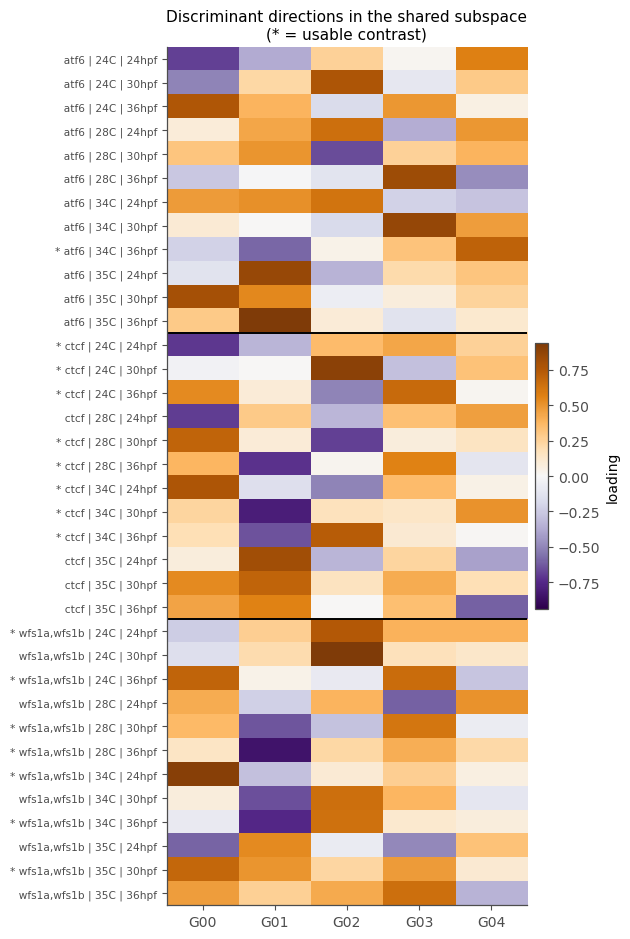

In [19]:
figure = lp.direction_heatmap(directions, summary)
lp.save_inline(figure, FIGURES / "10_direction_heatmap")


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/11_similarity_heatmap.png')

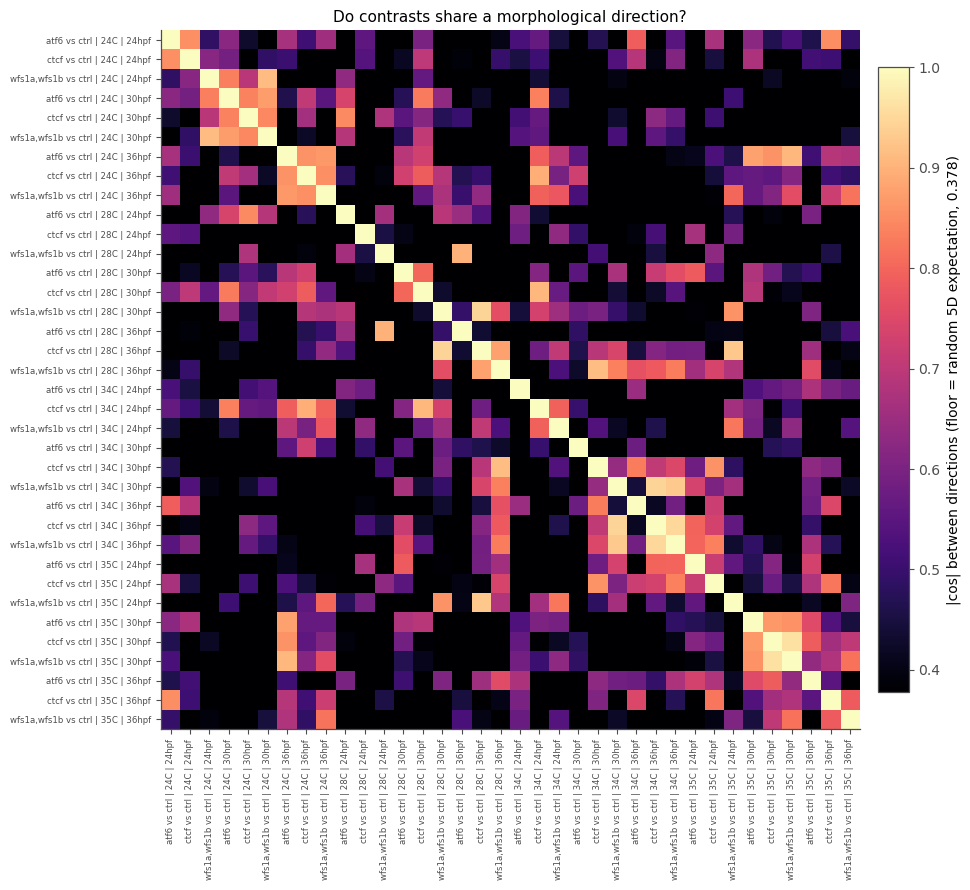

In [20]:
figure = lp.similarity_heatmap(similarity)
lp.save_inline(figure, FIGURES / "11_similarity_heatmap")


In [21]:
lc.direction_similarity_summary(
    axes, restrict_usable=summary.set_index("contrast")["usable"]
).round(4)


,comparison,n_pairs,mean_abs_cos,n_contrasts,p_vs_between,p_vs_random
0,within target,49,0.4293,16,0.5404,0.0780
1,between targets,71,0.4371,16,NaN,0.0312
2,random 5D floor,20000,0.3777,16,NaN,NaN


**A null result, and a clean one.** Restricted to contrasts with a usable axis, within-target
agreement is no higher than between-target agreement, and neither exceeds the random-direction floor.
So each contrast's discriminant is its own direction: `ctcf` at 24 °C and `ctcf` at 34 °C are not
finding the same morphological signature, any more than `ctcf` and `wfs1a/wfs1b` are.

This is the same non-commensurability that sank the intra-cohort PC approach, and it constrains what
comes next: coefficients can be *compared* across contrasts, but the predictor cannot be pooled, and
there is no "the atf6 morphology axis" to speak of.


## 8. What does the axis look like?

The check no statistic replaces. Every embryo in the contrast, ordered along `s`, controls in blue
and crispants in red. If the ordering tracked mounting angle or focus rather than biology, it would
be obvious here.

All 36 strips are written to `figures/lda/strips/`.


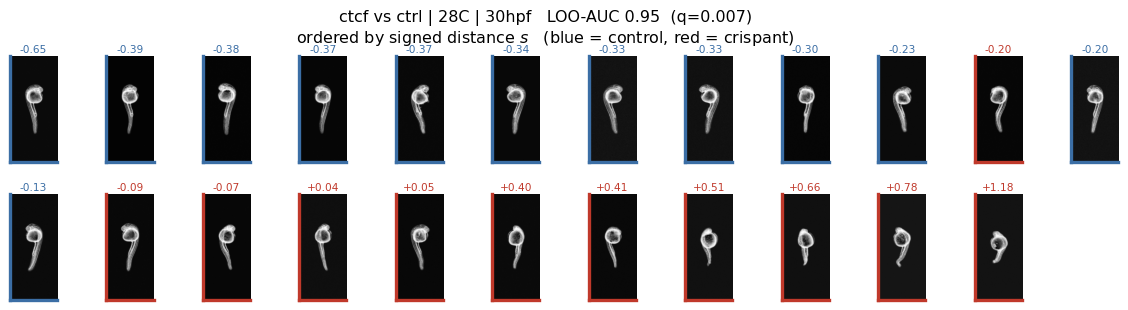

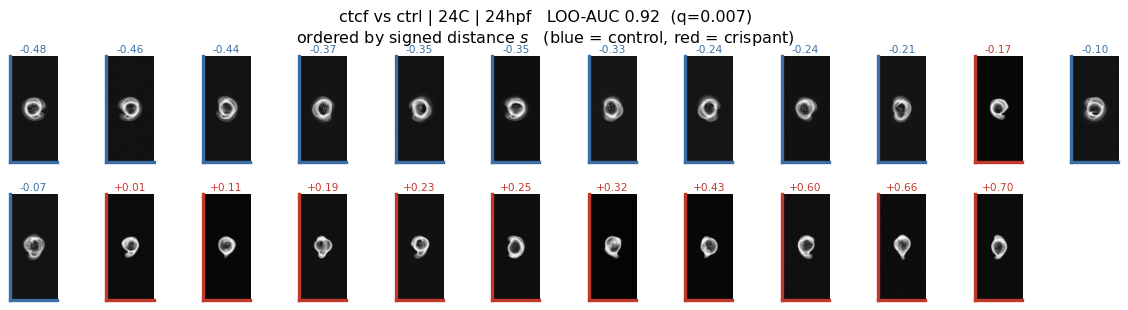

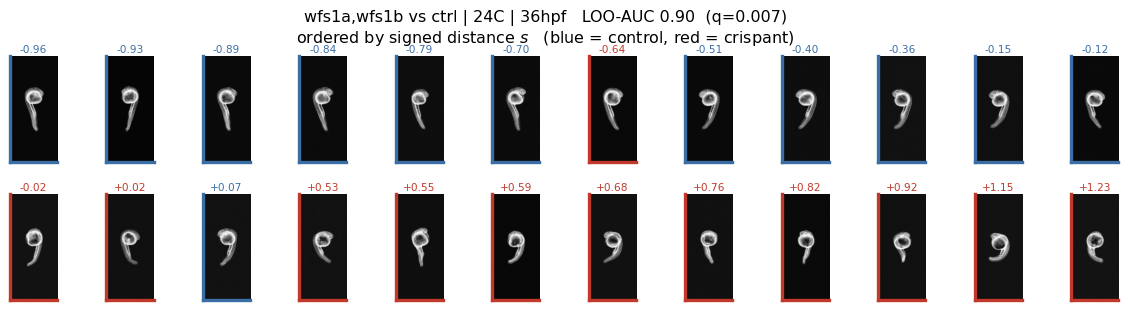

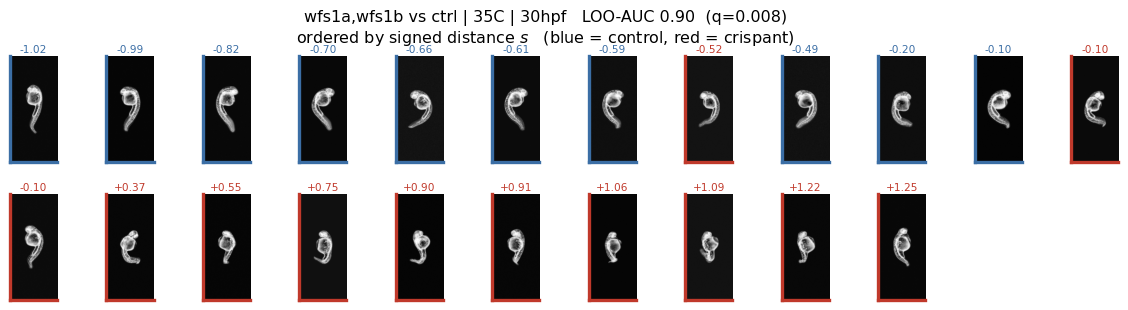

PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/12_contrast_strip_figure.png')

In [22]:
from IPython.display import Image, display

showcase = (
    summary.loc[summary["usable"]].sort_values("loo_auc", ascending=False)["contrast"].head(4)
)
for label in showcase:
    axis = next(a for a in axes if a.label == label)
    strip = lc.contrast_image_strip(axis)
    row = summary.loc[summary["contrast"] == label].iloc[0]
    figure = lp.contrast_strip_figure(
        strip, title=f"{label}   LOO-AUC {row['loo_auc']:.2f}  (q={row['q_auc']:.3f})"
    )
    display(figure)
    import matplotlib.pyplot as plt; plt.close(figure)
lp.save_inline(figure, FIGURES / "12_contrast_strip_figure")


For contrast, a failing axis — the one at AUC 0.02. Controls and crispants interleave along the
ordering, and no severity gradient is visible.


PosixPath('/net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/results/nlammers/20260730_GENE7/figures/lda_contrasts/13_contrast_strip_figure_2.png')

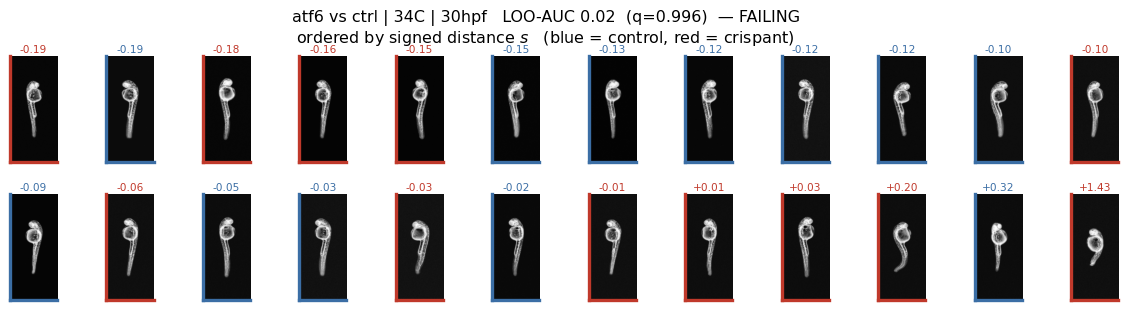

In [23]:
failing = summary.sort_values("loo_auc")["contrast"].iloc[0]
axis = next(a for a in axes if a.label == failing)
row = summary.loc[summary["contrast"] == failing].iloc[0]
figure = lp.contrast_strip_figure(
    lc.contrast_image_strip(axis),
    title=f"{failing}   LOO-AUC {row['loo_auc']:.2f}  (q={row['q_auc']:.3f})  — FAILING",
)
lp.save_inline(figure, FIGURES / "13_contrast_strip_figure_2")


## 9. Readout

The full table, sorted by how well the axis generalises.


In [24]:
summary.sort_values("loo_auc", ascending=False)[
    ["contrast", "n_crispant", "n_control", "loo_auc", "perm_p_auc", "q_auc",
     "separation", "hotelling_p", "boot_angle_p95", "angle_to_stage",
     "log_sd_ratio", "shrinkage", "usable"]
].round(3).reset_index(drop=True)


,contrast,n_crispant,n_control,loo_auc,perm_p_auc,q_auc,separation,hotelling_p,boot_angle_p95,angle_to_stage,log_sd_ratio,shrinkage,usable
0,ctcf vs ctrl | 28C | 30hpf,11,12,0.955,0.001,0.007,2.174,0.007,45.360,52.631,1.209,0.175,True
1,ctcf vs ctrl | 24C | 24hpf,11,12,0.917,0.001,0.007,2.574,0.001,31.717,30.388,0.733,0.535,True
2,"wfs1a,wfs1b vs ctrl | 24C | 36hpf",12,12,0.903,0.001,0.007,2.695,0.002,45.275,57.129,0.407,0.279,True
3,"wfs1a,wfs1b vs ctrl | 35C | 30hpf",12,10,0.900,0.002,0.008,2.717,0.003,43.567,48.909,0.667,0.241,True
4,"wfs1a,wfs1b vs ctrl | 34C | 24hpf",12,12,0.896,0.001,0.007,2.140,0.018,45.850,78.139,1.090,0.662,True
5,ctcf vs ctrl | 34C | 24hpf,12,12,0.896,0.002,0.008,1.626,0.047,45.047,89.552,1.148,0.547,True
6,ctcf vs ctrl | 34C | 30hpf,12,12,0.889,0.002,0.008,2.354,0.003,42.987,26.930,0.328,0.157,True
7,ctcf vs ctrl | 34C | 36hpf,11,12,0.864,0.003,0.011,1.977,0.045,54.847,45.864,1.534,0.374,True
8,"wfs1a,wfs1b vs ctrl | 28C | 30hpf",12,12,0.861,0.001,0.007,1.662,0.036,36.730,35.800,0.987,0.318,True
9,ctcf vs ctrl | 28C | 36hpf,12,11,0.848,0.005,0.016,1.846,0.021,52.961,35.284,1.315,0.199,True


In [25]:
by_target = summary.groupby("target").agg(
    n=("contrast", "size"),
    usable=("usable", "sum"),
    median_auc=("loo_auc", "median"),
    median_log_sd_ratio=("log_sd_ratio", "median"),
    median_angle_to_stage=("angle_to_stage", "median"),
).round(3)
by_temperature = summary.groupby("temperature").agg(
    n=("contrast", "size"),
    usable=("usable", "sum"),
    median_auc=("loo_auc", "median"),
).round(3)
display(by_target, by_temperature)


,n,usable,median_auc,median_log_sd_ratio,median_angle_to_stage
target,,,,,
atf6,12,1,0.572,0.559,59.542
ctcf,12,8,0.824,0.764,50.916
"wfs1a,wfs1b",12,7,0.787,0.488,58.097


,n,usable,median_auc
temperature,,,
24.0,9,5,0.764
28.0,9,4,0.603
34.0,9,6,0.848
35.0,9,1,0.590


### Where this leaves the regression plan

The score `s` is defensible as a regression predictor **only for the contrasts that clear both
gates**. For the rest, `s` is a direction fit to noise, and substituting it for the binary indicator
would cost power rather than gain it — the attenuation worry, realised.

Open items before any PLN fitting:

1. **Which arm of the comparison to fit.** Three one-predictor models with identical df — `~ binary`,
   `~ s`, and the hinge `~ pmax(s − c, 0)` — so raw log-likelihood is a fair head-to-head, with a
   sign test across contrasts.
2. **The hinge threshold `c`** should be the control mean or the hyperplane, not `min(s)` among
   crispants, which would hang the whole predictor on one embryo.
3. **Cosine between `β_s` and `β_binary`** per contrast. This is the geometric claim as a statistic:
   same direction, larger magnitude. High cosine with larger `|β|` means morphology sharpened the
   same vector rather than finding a different one.
4. **The stage-flagged contrasts** need a decision — exclude, or carry with the caveat.

None of that is run here.
